In [1]:
%pip install pandas numpy matplotlib openpyxl

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.8 MB 4.0 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.8 MB 4.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.8 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.8 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.8 MB 4.1 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.8 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 4.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 4.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 4.0 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 3.9 MB/s  0:00:02
   -------------------

In [2]:
%pip install statsmodels linearmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/11.3 MB 3.9 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.3 MB 3.8 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.3 MB 3.9 MB/s eta 0:00:03
   ------------- -------------------------- 3.9/11.3 MB 3.8 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.3 MB 3.9 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 3.7 MB/s eta 0:00:02
   ------------------------ --------------- 7.1/11.3 MB 3.8 MB/s eta 0:00:02
   ---------------------------- ----------- 8.1/11.3 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 4.0 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.3 MB 4.0 MB/s eta 0:00:01
   --

In [3]:
%pip freeze > ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path

for f in Path("../data/raw").iterdir():
    print(f.name)

UcdpPrioConflict_v26_1.csv
SIPRI-Milex-data-1949-2025_v1.2.xlsx
SOURCES.txt


In [2]:
import pandas as pd

raw = Path("../data/raw")

csv_files = list(raw.glob("*.csv"))
xlsx_files = list(raw.glob("*.xlsx"))
print("CSV trouvés :", [f.name for f in csv_files])
print("Excel trouvés :", [f.name for f in xlsx_files])

ucdp = pd.read_csv(csv_files[0])
print("\nUCDP :", ucdp.shape)
print(ucdp.columns.tolist())

xl = pd.ExcelFile(xlsx_files[0])
print("\nSIPRI, onglets :", xl.sheet_names)

CSV trouvés : ['UcdpPrioConflict_v26_1.csv']
Excel trouvés : ['SIPRI-Milex-data-1949-2025_v1.2.xlsx']

UCDP : (2816, 28)
['conflict_id', 'location', 'side_a', 'side_a_id', 'side_a_2nd', 'side_b', 'side_b_id', 'side_b_2nd', 'incompatibility', 'territory_name', 'year', 'intensity_level', 'cumulative_intensity', 'type_of_conflict', 'start_date', 'start_prec', 'start_date2', 'start_prec2', 'ep_end', 'ep_end_date', 'ep_end_prec', 'gwno_a', 'gwno_a_2nd', 'gwno_b', 'gwno_b_2nd', 'gwno_loc', 'region', 'version']

SIPRI, onglets : ['Front page', 'Regional totals', 'Local currency financial years', 'Local currency calendar years', 'Constant (2024) US$', 'Current US$', 'Share of GDP', 'Per capita', 'Share of Govt. spending', 'Footnotes']


In [6]:
import sys
print(sys.executable)

d:\articles\milex-conflits\.venv\Scripts\python.exe


In [7]:
%pip install pandas numpy matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
for c in ucdp.columns:
    print(c)

print()
ucdp[["conflict_id", "location", "year", "intensity_level", "type_of_conflict", "gwno_loc", "region"]].head(10)

conflict_id
location
side_a
side_a_id
side_a_2nd
side_b
side_b_id
side_b_2nd
incompatibility
territory_name
year
intensity_level
cumulative_intensity
type_of_conflict
start_date
start_prec
start_date2
start_prec2
ep_end
ep_end_date
ep_end_prec
gwno_a
gwno_a_2nd
gwno_b
gwno_b_2nd
gwno_loc
region
version



,conflict_id,location,year,intensity_level,type_of_conflict,gwno_loc,region
0,200,Bolivia,1946,2,3,145,5
1,200,Bolivia,1949,1,3,145,5
2,200,Bolivia,1952,1,3,145,5
3,200,Bolivia,1967,1,3,145,5
4,201,Cambodia (Kampuchea),1946,1,1,811,3
5,201,Cambodia (Kampuchea),1947,1,1,811,3
6,201,Cambodia (Kampuchea),1948,1,1,811,3
7,201,Cambodia (Kampuchea),1949,1,1,811,3
8,201,Cambodia (Kampuchea),1950,1,1,811,3
9,201,Cambodia (Kampuchea),1951,1,1,811,3


In [4]:
for s in xl.sheet_names:
    print(s)

const_sheet = [s for s in xl.sheet_names if "Constant" in s][0]
print("\nOnglet retenu :", const_sheet)

pd.read_excel(xl, sheet_name=const_sheet, header=None).head(12)

Front page
Regional totals
Local currency financial years
Local currency calendar years
Constant (2024) US$
Current US$
Share of GDP
Per capita
Share of Govt. spending
Footnotes

Onglet retenu : Constant (2024) US$


,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,"Military expenditure by country, in constant (...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Figures are in US $m., at constant 2024 prices...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Figures in blue are SIPRI estimates. Figures i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"""..."" = data unavailable. ""xxx"" = country did ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Country,NaN,Notes,1949,1950,1951,1952,1953,1954,1955,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Algeria,NaN,§4,xxx,xxx,xxx,xxx,xxx,xxx,xxx,...,12771.057022,12094.810558,11599.483834,12513.907107,12222.085137,11395.370277,11022.402088,19281.144486,21811.242555,24128.442879


In [5]:
df = pd.read_excel(xl, sheet_name=const_sheet, header=5)
df = df.rename(columns={"Country": "country"})

year_cols = [c for c in df.columns if str(c).isdigit()]
print("Années :", year_cols[0], "→", year_cols[-1], "(", len(year_cols), "colonnes )")

# Lignes de région : toutes les années vides (avant conversion)
is_header = df[year_cols].isna().all(axis=1)
print("\nLignes retirées (régions, titres) :")
print(df.loc[is_header, "country"].tolist())

df = df.loc[~is_header].copy()

# Format long : une ligne par pays et par année
sipri = df.melt(id_vars="country", value_vars=year_cols,
                var_name="year", value_name="milex_usd_m")
sipri["year"] = sipri["year"].astype(int)
sipri["milex_usd_m"] = pd.to_numeric(sipri["milex_usd_m"], errors="coerce")

print("\nPays :", sipri["country"].nunique())
print(sipri.dropna().shape)
sipri[sipri["country"] == "France"].tail(8)

Années : 1949 → 2025 ( 77 colonnes )

Lignes retirées (régions, titres) :
[nan, 'Africa', 'North Africa', 'sub-Saharan Africa', 'Americas', 'Central America and the Caribbean', 'North America', 'South America', 'Asia & Oceania', 'Oceania', 'South Asia', 'East Asia', 'South East Asia', 'Central Asia', 'Europe', 'Central Europe', 'Eastern Europe', 'Western Europe', 'Middle East']

Pays : 174
(8435, 3)


,country,year,milex_usd_m
12148,France,2018,54701.000109
12322,France,2019,56073.561441
12496,France,2020,58039.151684
12670,France,2021,60510.285345
12844,France,2022,60193.327247
13018,France,2023,60793.843584
13192,France,2024,63574.699213
13366,France,2025,64515.088592


In [6]:
ucdp[["conflict_id", "location", "year", "intensity_level", "type_of_conflict", "gwno_loc", "gwno_a", "gwno_b"]].head(10)

,conflict_id,location,year,intensity_level,type_of_conflict,gwno_loc,gwno_a,gwno_b
0,200,Bolivia,1946,2,3,145,145,NaN
1,200,Bolivia,1949,1,3,145,145,NaN
2,200,Bolivia,1952,1,3,145,145,NaN
3,200,Bolivia,1967,1,3,145,145,NaN
4,201,Cambodia (Kampuchea),1946,1,1,811,220,NaN
5,201,Cambodia (Kampuchea),1947,1,1,811,220,NaN
6,201,Cambodia (Kampuchea),1948,1,1,811,220,NaN
7,201,Cambodia (Kampuchea),1949,1,1,811,220,NaN
8,201,Cambodia (Kampuchea),1950,1,1,811,220,NaN
9,201,Cambodia (Kampuchea),1951,1,1,811,220,NaN


In [7]:
%pip install country_converter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import country_converter as coco

# 1. gwno_loc contient-il parfois plusieurs codes dans une même cellule ?
print("Type de gwno_loc :", ucdp["gwno_loc"].dtype)
multi = ucdp[ucdp["gwno_loc"].astype(str).str.contains(",")]
print("Lignes avec plusieurs codes :", len(multi))
print(multi[["location", "gwno_loc"]].drop_duplicates().head(), "\n")

# 2. Conversion des noms SIPRI en codes GW
countries = sorted(sipri["country"].dropna().unique())
codes = coco.convert(countries, to="GWcode", not_found=None)
mapping = pd.DataFrame({"country": countries, "gwno": codes})

print("Non reconnus par l'outil :")
print(mapping[mapping["gwno"].isna()]["country"].tolist())

European Union not found in regex
German Democratic Republic not found in regex
USSR not found in regex
Yugoslavia not found in regex


Type de gwno_loc : str
Lignes avec plusieurs codes : 159
                                        location                      gwno_loc
129                             France, Thailand                      220, 800
130                      Albania, United Kingdom                      200, 339
141                              India, Pakistan                      750, 770
353                             Hyderabad, India                      750, 751
395  Egypt, Iraq, Israel, Jordan, Lebanon, Syria  645, 651, 652, 660, 663, 666 

Non reconnus par l'outil :
[]


In [9]:
%pip install country_converter

Note: you may need to restart the kernel to use updated packages.


In [3]:
u = ucdp[ucdp["year"] >= 1992].copy()
u["gwno_num"] = pd.to_numeric(u["gwno_loc"], errors="coerce")

known = set(pd.to_numeric(mapping["gwno"], errors="coerce").dropna().astype(int))
orphans = u[~u["gwno_num"].isin(known)][["location", "gwno_loc"]].drop_duplicates()

print("Lieux de conflit UCDP (depuis 1992) sans pays SIPRI correspondant :")
orphans

Lieux de conflit UCDP (depuis 1992) sans pays SIPRI correspondant :


,location,gwno_loc
150,"India, Pakistan","750, 770"
421,Yemen (North Yemen),678
920,"China, India","710, 750"
1201,"Cambodia (Kampuchea), Thailand","800, 811"
1312,"Israel, Syria","652, 666"
2161,Serbia (Yugoslavia),345
2288,"Ecuador, Peru","130, 135"
2312,"Cameroon, Nigeria","471, 475"
2314,Comoros,581
2321,"Eritrea, Ethiopia","530, 531"


In [4]:
mapping["gwno"] = pd.to_numeric(mapping["gwno"], errors="coerce")

overrides = {"Yemen": 678, "Serbia": 345}
for name, code in overrides.items():
    mapping.loc[mapping["country"] == name, "gwno"] = code

print("Sans code :", mapping[mapping["gwno"].isna()]["country"].tolist())
print()
mapping[mapping["country"].str.contains("Yemen|Serbia|Comoros|Germany|Viet|Czech|Kosovo", regex=True)]

Sans code : ['European Union', 'German Democratic Republic', 'USSR', 'Yugoslavia']



,country,gwno
39,Czechia,315.0
40,Czechoslovakia,315.0
60,Germany,260.0
85,Kosovo,347.0
134,Serbia,345.0
168,Viet Nam,817.0
169,Yemen,678.0
170,"Yemen, North",680.0


In [5]:
u = ucdp[ucdp["year"] >= 1992].copy()
u["gwno_loc_single"] = u["gwno_loc"].astype(str).str.split(",")
u = u.explode("gwno_loc_single")
u["gwno_loc_single"] = pd.to_numeric(u["gwno_loc_single"].str.strip(), errors="coerce")
print("Lignes après découpage :", u.shape[0])

known = set(mapping["gwno"].dropna().astype(int))
orphans = u[~u["gwno_loc_single"].isin(known)][["location", "gwno_loc_single"]].drop_duplicates()
print("\nLieux UCDP sans pays SIPRI correspondant :")
orphans

Lignes après découpage : 1564

Lieux UCDP sans pays SIPRI correspondant :


,location,gwno_loc_single
2314,Comoros,581


In [6]:
inter = ucdp[(ucdp["year"] >= 1992) & (ucdp["type_of_conflict"] == 2)]
inter.drop_duplicates("conflict_id")[["conflict_id", "location", "gwno_a", "gwno_b", "gwno_loc"]]

,conflict_id,location,gwno_a,gwno_b,gwno_loc
150,218,"India, Pakistan",750,770,"750, 770"
920,274,"China, India",710,750,"710, 750"
1201,294,"Cambodia (Kampuchea), Thailand",811,800,"800, 811"
1312,302,"Israel, Syria",666,652,"652, 666"
2288,403,"Ecuador, Peru",130,135,"130, 135"
2312,405,"Cameroon, Nigeria",471,475,"471, 475"
2321,409,"Eritrea, Ethiopia",531,530,"530, 531"
2430,420,"Australia, Iraq, United Kingdom, United States...","900, 200, 2",645,"2, 200, 645, 900"
2503,435,"Djibouti, Eritrea",522,531,"522, 531"
2558,11348,"South Sudan, Sudan",626,625,"625, 626"


In [7]:
# 1. Corrections du tableau de correspondance
mapping.loc[mapping["country"] == "Serbia", "gwno"] = 340   # annule ma correction précédente
mapping.loc[mapping["country"] == "Yemen", "gwno"] = 678

exclude = ["European Union", "German Democratic Republic", "USSR", "Yugoslavia",
           "Czechoslovakia", "Yemen, North"]
mapping = mapping[~mapping["country"].isin(exclude)].copy()

# 2. UCDP depuis 1992 : une ligne par pays de conflit, Serbie 345 -> 340
u = ucdp[ucdp["year"] >= 1992].copy()
u["gwno_loc_single"] = u["gwno_loc"].astype(str).str.split(",")
u = u.explode("gwno_loc_single")
u["gwno_loc_single"] = pd.to_numeric(u["gwno_loc_single"].str.strip(), errors="coerce")
u["gwno_loc_single"] = u["gwno_loc_single"].replace({345: 340})

# 3. Contrôles
known = set(mapping["gwno"].dropna().astype(int))
orphans = u[~u["gwno_loc_single"].isin(known)][["location", "gwno_loc_single"]].drop_duplicates()
print("Orphelins UCDP :")
print(orphans, "\n")

print("Pays dans le tableau :", mapping.shape[0])
print("Codes en double :")
print(mapping[mapping.duplicated("gwno", keep=False)].sort_values("gwno"))

# 4. Sauvegarde
mapping.to_csv("../data/processed/mapping_pays.csv", index=False)

Orphelins UCDP :
     location  gwno_loc_single
2314  Comoros              581 

Pays dans le tableau : 168
Codes en double :
Empty DataFrame
Columns: [country, gwno]
Index: []


In [11]:
mapping["gwno"] = mapping["gwno"].astype(int)

# {conflict_id: [(année_de_début, [pays où se déroulent les combats]), ...]}
theatre_rules = {
    218:   [(0, [750, 770])],                   # Inde–Pakistan
    274:   [(0, [710, 750])],                   # Chine–Inde
    294:   [(0, [800, 811])],                   # Thaïlande–Cambodge
    302:   [(0, [652])],                        # Israël–Syrie : combats en Syrie
    403:   [(0, [130, 135])],                   # Équateur–Pérou
    405:   [(0, [471, 475])],                   # Cameroun–Nigeria
    409:   [(0, [530, 531])],                   # Éthiopie–Érythrée
    420:   [(0, [645])],                        # Irak 2003
    435:   [(0, [522, 531])],                   # Djibouti–Érythrée
    11348: [(0, [625, 626])],                   # Soudan du Sud–Soudan
    11639: [(0, [700, 770])],                   # Afghanistan–Pakistan
    13243: [(0, [369]), (2023, [365, 369])],    # sol russe touché à partir de 2023
    13324: [(0, [702, 703])],                   # Kirghizistan–Tadjikistan
    13692: [(0, [700])],                        # Afghanistan
    14609: [(0, [652]), (2024, [630, 666])],    # Syrie avant 2024, Iran+Israël ensuite
    16099: [(0, [678])],                        # États-Unis/Royaume-Uni–Yémen
    16470: [(0, [666, 678])],                   # Israël–Yémen
}

def theatre_for(cid, year):
    chosen = None
    for start, loc in sorted(theatre_rules.get(cid, [])):
        if year >= start:
            chosen = loc
    return chosen

def codes(x):
    if pd.isna(x):
        return []
    return [int(float(c)) for c in str(x).split(",") if c.strip()]

def fix(g):
    return 340 if g == 345 else g   # Serbie

rows, missing = [], []
for _, r in ucdp[ucdp["year"] >= 1992].iterrows():
    if r["type_of_conflict"] == 2:
        loc = theatre_for(r["conflict_id"], r["year"])
        if loc is None:
            missing.append(r["conflict_id"])
            continue
    else:
        loc = codes(r["gwno_loc"])

    bell = set(codes(r["gwno_a"]) + codes(r["gwno_b"]) +
               codes(r["gwno_a_2nd"]) + codes(r["gwno_b_2nd"]))
    bell = ";".join(str(fix(b)) for b in sorted(bell))

    for g in loc:
        rows.append({"conflict_id": r["conflict_id"], "year": r["year"],
                     "type": r["type_of_conflict"], "intensity": r["intensity_level"],
                     "gw_theatre": fix(g), "belligerents": bell})

theatre_df = pd.DataFrame(rows)
print("Interétatiques sans lieu défini :", sorted(set(missing)))
print("Lignes :", theatre_df.shape[0], "\n")

# Plages d'années des 5 conflits
def plages(annees):
    annees = sorted(annees)
    out, deb, prev = [], annees[0], annees[0]
    for a in annees[1:]:
        if a != prev + 1:
            out.append(f"{deb}-{prev}" if deb != prev else str(deb))
            deb = a
        prev = a
    out.append(f"{deb}-{prev}" if deb != prev else str(deb))
    return ", ".join(out)

for cid in [13243, 302, 14609, 16099, 16470]:
    ys = ucdp[(ucdp["conflict_id"] == cid) & (ucdp["year"] >= 1992)]["year"]
    print(cid, "→", plages(ys))

# Pays touchés en 2022, un par ligne
names = mapping.set_index("gwno")["country"]
sel = theatre_df[theatre_df["year"] == 2022]["gw_theatre"].unique()
print("\nPays touchés en 2022 :")
print("\n".join(sorted(names.reindex(sel).fillna("hors SIPRI").tolist())))

theatre_df.to_csv("../data/processed/theatres_conflits.csv", index=False)

Interétatiques sans lieu défini : []
Lignes : 1547 

13243 → 2022-2025
302 → 2025
14609 → 2018-2025
16099 → 2024-2025
16470 → 2025

Pays touchés en 2022 :
Afghanistan
Angola
Azerbaijan
Benin
Burkina Faso
Burundi
Cameroon
Central African Republic
Chad
Colombia
Congo, DR
Egypt
Ethiopia
India
Indonesia
Iraq
Israel
Kenya
Kyrgyz Republic
Mali
Mozambique
Myanmar
Niger
Nigeria
Pakistan
Philippines
Rwanda
Somalia
Sudan
Syria
Tajikistan
Thailand
Togo
Türkiye
Uganda
Ukraine
Yemen


In [9]:
ids = [13243, 302, 14609, 16099, 16470]
sub = ucdp[(ucdp["conflict_id"].isin(ids)) & (ucdp["year"] >= 1992)]

resume = sub.groupby("conflict_id").agg(
    annees=("year", lambda s: ", ".join(str(y) for y in sorted(s))),
    camp_a=("side_a", "first"),
    camp_b=("side_b", "first"),
    territoire=("territory_name", "first"),
)
print(resume.to_string())

                                                     annees                                                                camp_a                             camp_b                               territoire
conflict_id                                                                                                                                                                                                  
302                                                    2025                                                  Government of Israel                Government of Syria                            Golan Heights
13243                                2022, 2023, 2024, 2025                                   Government of Russia (Soviet Union)              Government of Ukraine                                   Crimea
14609        2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025                                                    Government of Iran               Government of Israel            

In [12]:
# 1. Comment UCDP code-t-il l'Ukraine ?
print(ucdp[ucdp["location"].str.contains("Ukraine")]
      [["conflict_id", "location", "year", "type_of_conflict", "intensity_level"]].to_string())

# 2. Contrôle des pays touchés en 2022 (la liste complète est trop longue)
sel = theatre_df[theatre_df["year"] == 2022]["gw_theatre"].unique()
liste = sorted(names.reindex(sel).fillna("hors SIPRI").tolist())
print("\n", len(liste), "pays touchés en 2022")
print([p for p in liste if any(k in p for k in
      ["France", "Germany", "United States", "USA", "Russia", "Myanmar", "Israel", "Syria"])])

      conflict_id                        location  year  type_of_conflict  intensity_level
2583        13219                         Ukraine  2014                 3                1
2584        13243  Russia (Soviet Union), Ukraine  2022                 2                2
2587        13243  Russia (Soviet Union), Ukraine  2023                 2                2
2588        13246                         Ukraine  2014                 4                2
2591        13247                         Ukraine  2014                 4                2
2594        13306                         Ukraine  2014                 4                2
2596        13243  Russia (Soviet Union), Ukraine  2024                 2                2
2597        13243  Russia (Soviet Union), Ukraine  2025                 2                2
2598        13306                         Ukraine  2015                 4                2
2599        13306                         Ukraine  2016                 4                1

In [13]:
b = theatre_df[theatre_df["gw_theatre"] == 369][["conflict_id", "year", "type", "intensity", "belligerents"]]
print(b.sort_values(["year", "conflict_id"]).to_string())

      conflict_id  year  type  intensity belligerents
1306        13219  2014     3          1          369
1312        13246  2014     4          2      365;369
1315        13247  2014     4          2      365;369
1318        13306  2014     4          2      365;369
1324        13306  2015     4          2      365;369
1325        13306  2016     4          1      365;369
1326        13306  2017     4          1      365;369
1327        13306  2018     4          1      365;369
1328        13306  2019     4          1      365;369
1329        13306  2020     4          1      365;369
1330        13306  2021     4          1      365;369
1307        13243  2022     2          2      365;369
1331        13306  2022     4          1      365;369
1311        13243  2023     2          2      365;369
1321        13243  2024     2          2  365;369;731
1323        13243  2025     2          2  365;369;731


In [14]:
cy = (theatre_df.groupby(["gw_theatre", "year"])
      .agg(max_intensity=("intensity", "max"),
           interstate=("type", lambda s: int((s == 2).any())),
           n_conflicts=("conflict_id", "nunique"))
      .reset_index()
      .rename(columns={"gw_theatre": "gwno"}))
cy["country"] = cy["gwno"].map(names)

print("Lignes pays-année :", cy.shape[0])
print(cy[cy["gwno"] == 369].to_string())

cy.to_csv("../data/processed/conflits_pays_annee.csv", index=False)

Lignes pays-année : 1050
     gwno  year  max_intensity  interstate  n_conflicts  country
118   369  2014              2           0            4  Ukraine
119   369  2015              2           0            1  Ukraine
120   369  2016              1           0            1  Ukraine
121   369  2017              1           0            1  Ukraine
122   369  2018              1           0            1  Ukraine
123   369  2019              1           0            1  Ukraine
124   369  2020              1           0            1  Ukraine
125   369  2021              1           0            1  Ukraine
126   369  2022              2           1            2  Ukraine
127   369  2023              2           1            1  Ukraine
128   369  2024              2           1            1  Ukraine
129   369  2025              2           1            1  Ukraine


In [15]:
%pip install geopandas

   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
    --------------------------------------- 0.5/23.8 MB 3.6 MB/s eta 0:00:07
   --- ------------------------------------ 2.1/23.8 MB 6.6 MB/s eta 0:00:04
   ------- -------------------------------- 4.2/23.8 MB 7.6 MB/s eta 0:00:03
   ---------- ----------------------------- 6.0/23.8 MB 8.0 MB/s eta 0:00:03
   ------------ --------------------------- 7.6/23.8 MB 7.8 MB/s eta 0:00:03
   --------------- ------------------------ 9.2/23.8 MB 7.8 MB/s eta 0:00:02
   ------------------ --------------------- 11.0/23.8 MB 7.9 MB/s eta 0:00:02
   --------------------- ------------------ 12.8/23.8 MB 8.0 MB/s eta 0:00:02
   ------------------------ --------------- 14.4/23.8 MB 8.0 MB/s eta 0:00:02
   --------------------------- ------------ 16.3/23.8 MB 8.1 MB/s eta 0:00:01
   ------------------------------ --------- 18.1/23.8 MB 8.1 MB/s eta 0:00:01
   --------------------------------- ------ 19.9/23.8 MB 8.2 MB/s eta 0:00:01


In [2]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

raw = Path("../data/raw")
cands = list(raw.rglob("*.geojson")) + list(raw.rglob("*.shp")) + list(raw.rglob("*.gpkg"))
print([str(c.relative_to(raw)) for c in cands])

cs = gpd.read_file(cands[0])
print(cs.shape)
print(cs.columns.tolist())
print(cs.drop(columns="geometry").head(5).to_string())

['CShapes-2.0.geojson']
(710, 16)
['cntry_name', 'area', 'capname', 'caplong', 'caplat', 'gwcode', 'gwsdate', 'gwsyear', 'gwsmonth', 'gwsday', 'gwedate', 'gweyear', 'gwemonth', 'gweday', 'cap_geom', 'geometry']
                 cntry_name       area     capname   caplong   caplat  gwcode              gwsdate  gwsyear  gwsmonth  gwsday              gwedate  gweyear  gwemonth  gweday                                                 cap_geom
0  United States of America  7940050.0  Washington  -77.0367  38.8950       2  31.12.1885 23:00:00     1886         1       1  01.01.1959 23:00:00     1959         1       2   SRID=4326;POINT (-77.03666687011719 38.89500045776367)
1  United States of America  9446290.0  Washington  -77.0367  38.8950       2  02.01.1959 23:00:00     1959         1       3  19.08.1959 23:00:00     1959         8      20   SRID=4326;POINT (-77.03666687011719 38.89500045776367)
2  United States of America  9462980.0  Washington  -77.0367  38.8950       2  20.08.1959 23:00:

In [1]:
#CELLULE QUI RECHARGE

import pandas as pd
from pathlib import Path

raw = Path("../data/raw")

ucdp = pd.read_csv(raw / "UcdpPrioConflict_v26_1.csv")
xl = pd.ExcelFile(raw / "SIPRI-Milex-data-1949-2025_v1.2.xlsx")

# SIPRI : chargement, retrait des régions, passage au format long
const_sheet = "Constant (2024) US$"
df = pd.read_excel(xl, sheet_name=const_sheet, header=5)
df = df.rename(columns={"Country": "country"})
year_cols = [c for c in df.columns if str(c).isdigit()]
is_header = df[year_cols].isna().all(axis=1)
df = df.loc[~is_header].copy()

sipri = df.melt(id_vars="country", value_vars=year_cols,
                var_name="year", value_name="milex_usd_m")
sipri["year"] = sipri["year"].astype(int)
sipri["milex_usd_m"] = pd.to_numeric(sipri["milex_usd_m"], errors="coerce")

print("UCDP :", ucdp.shape)
print("SIPRI : pays =", sipri["country"].nunique(), "| valeurs =", sipri.dropna().shape[0])

UCDP : (2816, 28)
SIPRI : pays = 174 | valeurs = 8435


In [3]:
import pandas as pd
mapping = pd.read_csv("../data/processed/mapping_pays.csv")
cy = pd.read_csv("../data/processed/conflits_pays_annee.csv")
theatre_df = pd.read_csv("../data/processed/theatres_conflits.csv")
names = mapping.set_index("gwno")["country"]

In [4]:
# 1. Inspection complète
for c in cs.columns:
    if c != "geometry":
        print(f"{c:12s} {str(cs[c].dtype):10s} exemple : {cs[c].iloc[0]}")
print("\nCRS :", cs.crs)

# 2. Valeurs des colonnes de statut éventuelles
for c in cs.columns:
    if c.lower() in ("status", "owner", "b_def", "gweyear"):
        print("\n", c, "→", cs[c].value_counts(dropna=False).head(8).to_dict())

cntry_name   str        exemple : United States of America
area         float64    exemple : 7940050.0
capname      str        exemple : Washington
caplong      float64    exemple : -77.0367
caplat       float64    exemple : 38.895
gwcode       int32      exemple : 2
gwsdate      str        exemple : 31.12.1885 23:00:00
gwsyear      int32      exemple : 1886
gwsmonth     int32      exemple : 1
gwsday       int32      exemple : 1
gwedate      str        exemple : 01.01.1959 23:00:00
gweyear      int32      exemple : 1959
gwemonth     int32      exemple : 1
gweday       int32      exemple : 2
cap_geom     str        exemple : SRID=4326;POINT (-77.03666687011719 38.89500045776367)

CRS : EPSG:4326

 gweyear → {2019: 181, 1920: 27, 1919: 23, 1960: 19, 1918: 14, 1900: 14, 1902: 13, 1914: 12}


In [5]:
# 1. Instantané au 31/12/2019 : une ligne par État existant à cette date
snap = cs[(cs["gwsyear"] <= 2019) & (cs["gweyear"] >= 2019)].copy()
print("Lignes :", len(snap), "| codes uniques :", snap["gwcode"].nunique())
print("Capitales sans coordonnées :", snap[["caplong", "caplat"]].isna().any(axis=1).sum())

# 2. Les pays SIPRI ont-ils un code dans CShapes ?
snap_codes = set(snap["gwcode"])
manque = mapping[~mapping["gwno"].isin(snap_codes)]
print("\nPays SIPRI absents de CShapes :")
print(manque.to_string() if len(manque) else "aucun")

# 3. Les pays touchés par un conflit ont-ils un code dans CShapes ?
codes_conflit = set(cy["gwno"].astype(int))
print("\nCodes de conflit absents de CShapes :", sorted(codes_conflit - snap_codes))

# 4. États CShapes sans données SIPRI
sans_sipri = snap[~snap["gwcode"].isin(set(mapping["gwno"]))]
print("\nÉtats CShapes sans données SIPRI :", len(sans_sipri))
print(sorted(sans_sipri["cntry_name"].tolist()))

Lignes : 181 | codes uniques : 181
Capitales sans coordonnées : 0

Pays SIPRI absents de CShapes :
        country   gwno
39      Czechia  315.0
132  Seychelles  591.0
164    Viet Nam  817.0

Codes de conflit absents de CShapes : []

États CShapes sans données SIPRI : 16
['Bahamas', 'Barbados', 'Bhutan', 'Comoros', 'Czech Republic', 'French Guyana', 'French Polynesia', 'Guadeloupe', 'Maldives', 'Martinique', 'New Caledonia and Dependencies', 'Puerto Rico', 'Reunion', 'Solomon Islands', 'Surinam', 'Vietnam, Democratic Republic of']


In [6]:
import numpy as np

snap = snap.sort_values("gwcode").reset_index(drop=True)
R = 6371.0088  # rayon moyen de la Terre, en km
lat = np.radians(snap["caplat"].to_numpy())
lon = np.radians(snap["caplong"].to_numpy())

a = (np.sin((lat[:, None] - lat[None, :]) / 2) ** 2
     + np.cos(lat[:, None]) * np.cos(lat[None, :])
     * np.sin((lon[:, None] - lon[None, :]) / 2) ** 2)
capdist = pd.DataFrame(2 * R * np.arcsin(np.sqrt(a)),
                       index=snap["gwcode"], columns=snap["gwcode"])

print("Paris–Londres     :", round(capdist.loc[220, 200]), "km (attendu ≈ 344)")
print("Kiev–Varsovie     :", round(capdist.loc[369, 290]), "km (attendu ≈ 690)")
print("Kiev–Moscou       :", round(capdist.loc[369, 365]), "km (attendu ≈ 755)")
print("Washington–Moscou :", round(capdist.loc[2, 365]), "km (attendu ≈ 7 800)")

capdist.to_csv("../data/processed/capdist_2019.csv")

Paris–Londres     : 341 km (attendu ≈ 344)
Kiev–Varsovie     : 691 km (attendu ≈ 690)
Kiev–Moscou       : 757 km (attendu ≈ 755)
Washington–Moscou : 7822 km (attendu ≈ 7 800)


In [7]:
# 1. Ce que CShapes contient pour ces pays
cible = snap[snap["cntry_name"].str.contains("Czech|Viet|Seychel|Slovak", case=False)]
print(cible[["cntry_name", "gwcode", "capname"]].to_string())

# 2. Application des corrections (uniquement si la recherche donne un résultat unique)
def code_cshapes(motif):
    m = snap[snap["cntry_name"].str.contains(motif, case=False)]
    return int(m["gwcode"].iloc[0]) if len(m) == 1 else None

for pays, motif in {"Czechia": "Czech", "Viet Nam": "Viet"}.items():
    c = code_cshapes(motif)
    print(f"\n{pays} → nouveau code : {c}")
    if c is not None:
        mapping.loc[mapping["country"] == pays, "gwno"] = c

mapping = mapping[mapping["country"] != "Seychelles"].copy()

# 3. Recontrôle
manque = mapping[~mapping["gwno"].isin(set(snap["gwcode"]))]
print("\nPays SIPRI encore absents de CShapes :", manque["country"].tolist())
print("Pays dans le panel :", len(mapping))
print("Codes en double :", mapping["gwno"].duplicated().sum())

mapping.to_csv("../data/processed/mapping_pays.csv", index=False)
names = mapping.set_index("gwno")["country"]

# 4. Liste complète des États CShapes sans SIPRI (ton affichage était coupé)
print("\n", sorted(sans_sipri["cntry_name"].tolist()))

                          cntry_name  gwcode     capname
46                    Czech Republic     316      Prague
47                          Slovakia     317  Bratislava
63             Russia (Soviet Union)     365      Moscow
167  Vietnam, Democratic Republic of     816       Hanoi

Czechia → nouveau code : 316

Viet Nam → nouveau code : None

Pays SIPRI encore absents de CShapes : ['Viet Nam']
Pays dans le panel : 167
Codes en double : 0

 ['Bahamas', 'Barbados', 'Bhutan', 'Comoros', 'Czech Republic', 'French Guyana', 'French Polynesia', 'Guadeloupe', 'Maldives', 'Martinique', 'New Caledonia and Dependencies', 'Puerto Rico', 'Reunion', 'Solomon Islands', 'Surinam', 'Vietnam, Democratic Republic of']


In [8]:
mapping["gwno"] = mapping["gwno"].astype(int)
mapping.loc[mapping["country"] == "Viet Nam", "gwno"] = 816   # Hanoï, confirmé par CShapes

manque = mapping[~mapping["gwno"].isin(set(snap["gwcode"]))]
print("Pays SIPRI absents de CShapes :", manque["country"].tolist())
print("Pays dans le panel :", len(mapping), "| codes en double :", mapping["gwno"].duplicated().sum())

mapping.to_csv("../data/processed/mapping_pays.csv", index=False)
names = mapping.set_index("gwno")["country"]

Pays SIPRI absents de CShapes : []
Pays dans le panel : 167 | codes en double : 0


In [9]:
import numpy as np

# 1. Panel de base : dépenses SIPRI + codes pays, croissance annuelle en log
panel = sipri.merge(mapping, on="country", how="inner")
panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)
panel["milex_usd_m"] = panel["milex_usd_m"].where(panel["milex_usd_m"] > 0)  # 0 -> manquant (log impossible)
panel["log_milex"] = np.log(panel["milex_usd_m"])
panel["dlog_milex"] = panel.groupby("gwno")["log_milex"].diff()
panel = panel[(panel["year"] >= 1992) & (panel["year"] <= 2025)].copy()

# 2. Conflits actifs par année : théâtres, belligérants, intensité, type
t = theatre_df.copy()
t["belligerents"] = t["belligerents"].fillna("").astype(str)
conf = (t.groupby(["conflict_id", "year"])
          .agg(theatres=("gw_theatre", lambda s: sorted(set(int(x) for x in s))),
               intensity=("intensity", "max"),
               ctype=("type", "first"),
               bell=("belligerents", "first"))
          .reset_index())
conf["bell"] = conf["bell"].apply(lambda s: {int(x) for x in s.split(";") if x})

# 3. Distance au conflit le plus proche (hors conflits où le pays est impliqué)
cap = capdist
codes = sorted(int(x) for x in panel["gwno"].unique())
assert all(g in cap.index for g in codes), "code absent de la table de distances"

out = []
for year, sub in conf.groupby("year"):
    items = [(r.theatres, r.bell, r.intensity, r.ctype) for r in sub.itertuples()]
    for g in codes:
        d_any = d_war = d_inter = np.inf
        own = 0
        for theatres, bell, inten, typ in items:
            if g in bell or g in theatres:
                own = 1
                continue
            d = min(cap.at[g, j] for j in theatres)
            d_any = min(d_any, d)
            if inten == 2:
                d_war = min(d_war, d)
            if typ == 2:
                d_inter = min(d_inter, d)
        out.append((g, year, d_any, d_war, d_inter, own))

expo = pd.DataFrame(out, columns=["gwno", "year", "d_any", "d_war", "d_inter", "own_conflict"])
expo[["d_any", "d_war", "d_inter"]] = expo[["d_any", "d_war", "d_inter"]].replace(np.inf, np.nan)
panel = panel.merge(expo, on=["gwno", "year"], how="left")

# 4. Exposition aux trois seuils, puis chocs (>= 3 ans sans exposition avant)
for D in (500, 1000, 2000):
    panel[f"exp_{D}"] = (panel["d_any"] <= D).astype(int)

panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)
g = panel.groupby("gwno")["exp_1000"]
panel["shock_1000"] = ((panel["exp_1000"] == 1) & (g.shift(1) == 0)
                       & (g.shift(2) == 0) & (g.shift(3) == 0)).astype(int)

# 5. Diagnostics
print("Lignes :", len(panel), "| pays :", panel["gwno"].nunique())
print("Croissance renseignée :", panel["dlog_milex"].notna().sum())
print("Part de pays-années impliqués dans un conflit :", round(panel["own_conflict"].mean(), 3))
print("\nPart de pays-années exposés :")
print(panel[["exp_500", "exp_1000", "exp_2000"]].mean().round(3).to_string())
print("\nChocs (1000 km) par année :")
print(panel[panel["shock_1000"] == 1].groupby("year").size().to_string())
print("\nChocs en 2014, 2022, 2023 :")
print(panel[(panel["shock_1000"] == 1) & panel["year"].isin([2014, 2022, 2023])]
      [["country", "year", "d_any"]].round(0).to_string(index=False))

chk = panel[panel["country"].isin(["Poland", "Finland", "Lithuania", "Germany", "France", "Romania"])
            & panel["year"].isin([2013, 2014, 2021, 2022, 2023])]
print("\nDistance au conflit le plus proche (km) :")
print(chk.pivot(index="country", columns="year", values="d_any").round(0))

panel.to_csv("../data/processed/panel_pays_annee.csv", index=False)

Lignes : 5678 | pays : 167
Croissance renseignée : 4827
Part de pays-années impliqués dans un conflit : 0.414

Part de pays-années exposés :
exp_500     0.125
exp_1000    0.462
exp_2000    0.804

Chocs (1000 km) par année :
year
1995     1
1996     3
1997     2
1998     7
2001     3
2002     4
2003     6
2004     5
2005     2
2006     1
2007     3
2008     2
2009     2
2010     3
2011     4
2013    10
2014     4
2015     2
2016     2
2017     1
2018     2
2019     2
2020     3
2021     1
2023     4
2024     1
2025     4

Chocs en 2014, 2022, 2023 :
     country  year  d_any
      Poland  2014  691.0
     Hungary  2014  895.0
      Serbia  2014  977.0
      Russia  2014  757.0
 Gambia, The  2023  938.0
      Guinea  2023  708.0
     Liberia  2023  767.0
Sierra Leone  2023  736.0

Distance au conflit le plus proche (km) :
year         2013    2014    2021    2022    2023
country                                          
Finland     893.0   893.0  1138.0  1138.0   893.0
France     1347.0 

In [10]:
# 1. Chocs (définition validée) : total et répartition par période de 5 ans
s = panel[panel["shock_1000"] == 1]
print("Chocs (1000 km) :", len(s), "| pays concernés :", s["gwno"].nunique())
print(s.groupby((s["year"] // 5) * 5).size().to_string())

for y in (2014, 2022, 2023):
    print(f"\n{y} :", s[s["year"] == y]["country"].tolist())

# 2. Variante "guerre" : conflit d'intensité 2 à moins de 1000 km, après >= 3 ans sans
panel["exp_war_1000"] = (panel["d_war"] <= 1000).astype(int)
gw = panel.groupby("gwno")["exp_war_1000"]
panel["shock_war_1000"] = ((panel["exp_war_1000"] == 1) & (gw.shift(1) == 0)
                           & (gw.shift(2) == 0) & (gw.shift(3) == 0)).astype(int)
sw = panel[panel["shock_war_1000"] == 1]
print("\nChocs guerre (1000 km) :", len(sw), "| pays concernés :", sw["gwno"].nunique())
for y in (2014, 2022):
    print(f"{y} :", sw[sw["year"] == y]["country"].tolist())

# 3. own_conflict : combien de pays par année, et lesquels le plus souvent
print("\nPays impliqués par année :")
print(panel.groupby("year")["own_conflict"].sum().loc[[1992, 2000, 2010, 2020, 2024]].to_string())
print("\nPays les plus souvent impliqués :")
print(panel.groupby("country")["own_conflict"].sum().sort_values(ascending=False).head(15).to_string())

panel.to_csv("../data/processed/panel_pays_annee.csv", index=False)

Chocs (1000 km) : 84 | pays concernés : 60
year
1995    13
2000    18
2005    10
2010    21
2015     9
2020     9
2025     4

2014 : ['Poland', 'Hungary', 'Serbia', 'Russia']

2022 : []

2023 : ['Gambia, The', 'Guinea', 'Liberia', 'Sierra Leone']

Chocs guerre (1000 km) : 141 | pays concernés : 72
2014 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Kenya', 'Burundi', 'Rwanda']
2022 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Guinea-Bissau', 'Mali', "Cote d'Ivoire", 'Bangladesh', 'Thailand', 'Laos']

Pays impliqués par année :
year
1992    41
2000    33
2010    71
2020    99
2024    84

Pays les plus souvent impliqués :
country
Afghanistan       34
Colombia          34
Sudan             34
Myanmar           34
Philippines       34
Türkiye           34
India             34
Pakistan          33
Uganda            33
Ethiopia          33
Chad              31
Russia            31
Israel            30
B

In [12]:
def codes(x):
    if pd.isna(x):
        return []
    return [int(float(c)) for c in str(x).split(",") if c.strip()]

def fix(g):
    return 340 if g == 345 else g

# Implication directe : belligérant principal (colonnes a/b) ou théâtre
prim = []
for r in ucdp[ucdp["year"] >= 1992].itertuples():
    for c in codes(r.gwno_a) + codes(r.gwno_b):
        prim.append((fix(c), r.year))
th = theatre_df[["gw_theatre", "year"]].drop_duplicates()
prim += list(zip(th["gw_theatre"], th["year"]))
prim_cy = pd.DataFrame(prim, columns=["gwno", "year"]).drop_duplicates()
prim_cy["own_primary"] = 1

panel = panel.drop(columns=["own_primary"], errors="ignore")
panel = panel.merge(prim_cy, on=["gwno", "year"], how="left")
panel["own_primary"] = panel["own_primary"].fillna(0).astype(int)

print("Pays impliqués par année (tous rôles / directement) :")
res = panel.groupby("year")[["own_conflict", "own_primary"]].sum()
print(res.loc[[1992, 2000, 2010, 2020, 2024]].to_string())

solo = panel[(panel["own_conflict"] == 1) & (panel["own_primary"] == 0)]
print("\nPays le plus souvent 'soutien seulement' :")
print(solo.groupby("country").size().sort_values(ascending=False).head(12).to_string())

Pays impliqués par année (tous rôles / directement) :
      own_conflict  own_primary
year                           
1992            41           37
2000            33           29
2010            71           25
2020            99           39
2024            84           36

Pays le plus souvent 'soutien seulement' :
country
France            26
Canada            25
Netherlands       25
Norway            25
Germany           24
Romania           24
Italy             24
Denmark           23
Portugal          23
Australia         23
United Kingdom    23
Spain             23


In [13]:
def plus_proche(g, year):
    best = None
    for r in conf[conf["year"] == year].itertuples():
        if g in r.bell or g in r.theatres:
            continue
        d = min(capdist.at[g, j] for j in r.theatres)
        if best is None or d < best[0]:
            best = (round(d), int(r.conflict_id), [names.get(x, x) for x in r.theatres])
    return best

for pays, y in [("Hungary", 2013), ("Hungary", 2014), ("Serbia", 2013), ("Serbia", 2014),
                ("Gambia, The", 2022), ("Gambia, The", 2023), ("Guinea", 2022), ("Guinea", 2023),
                ("Liberia", 2022), ("Liberia", 2023), ("Sierra Leone", 2022), ("Sierra Leone", 2023)]:
    g = int(mapping.loc[mapping["country"] == pays, "gwno"].iloc[0])
    print(pays, y, "→ conflit le plus proche :", plus_proche(g, y))

Hungary 2013 → conflit le plus proche : (1388, 354, ['Türkiye'])
Hungary 2014 → conflit le plus proche : (895, 13306, ['Ukraine'])
Serbia 2013 → conflit le plus proche : (1153, 354, ['Türkiye'])
Serbia 2014 → conflit le plus proche : (977, 13306, ['Ukraine'])
Gambia, The 2022 → conflit le plus proche : (1637, 360, ['Burkina Faso'])
Gambia, The 2023 → conflit le plus proche : (938, 16038, ['Mali'])
Guinea 2022 → conflit le plus proche : (1361, 360, ['Burkina Faso'])
Guinea 2023 → conflit le plus proche : (708, 16038, ['Mali'])
Liberia 2022 → conflit le plus proche : (1221, 13840, ['Burkina Faso'])
Liberia 2023 → conflit le plus proche : (767, 16038, ['Mali'])
Sierra Leone 2022 → conflit le plus proche : (1351, 13840, ['Burkina Faso'])
Sierra Leone 2023 → conflit le plus proche : (736, 16038, ['Mali'])


In [14]:
panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)

for col, tag in [("own_conflict", "any"), ("own_primary", "prim")]:
    gg = panel.groupby("gwno")[col]
    w = sum(gg.shift(k) for k in range(0, 4))      # implication de t-3 à t
    panel[f"clean_{tag}"] = (w == 0).astype(int)

for shock in ["shock_1000", "shock_war_1000"]:
    s = panel[panel[shock] == 1]
    a = s[s["clean_any"] == 1]
    p = s[s["clean_prim"] == 1]
    print(f"\n{shock} : {len(s)} chocs au départ")
    print(f"  sans aucune implication  : {len(a)} chocs, {a['gwno'].nunique()} pays")
    print(f"  sans implication directe : {len(p)} chocs, {p['gwno'].nunique()} pays")

sw = panel[(panel["shock_war_1000"] == 1) & (panel["clean_any"] == 1)]
for y in (2014, 2022):
    print(f"\nChocs guerre {y} (sans implication) :", sw[sw["year"] == y]["country"].tolist())

panel.to_csv("../data/processed/panel_pays_annee.csv", index=False)


shock_1000 : 84 chocs au départ
  sans aucune implication  : 40 chocs, 32 pays
  sans implication directe : 64 chocs, 46 pays

shock_war_1000 : 141 chocs au départ
  sans aucune implication  : 54 chocs, 41 pays
  sans implication directe : 91 chocs, 54 pays

Chocs guerre 2014 (sans implication) : ['Belarus']

Chocs guerre 2022 (sans implication) : ['Poland', 'Hungary', 'Belarus', 'Guinea-Bissau', 'Laos']


In [15]:
loc = ucdp.drop_duplicates("conflict_id").set_index("conflict_id")["location"]

# 1. Pourquoi ces pays sont-ils écartés par la règle "aucune implication" ?
for pays in ["Poland", "Latvia", "Romania"]:
    g = int(mapping.loc[mapping["country"] == pays, "gwno"].iloc[0])
    r = conf[conf["year"].between(2011, 2014) & conf["bell"].apply(lambda b: g in b)]
    print(pays, "soutien 2011-2014 →", sorted({loc[c] for c in r["conflict_id"]}))

# 2. Chocs guerre avec la règle principale (implication directe exclue)
sp = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1)]
print("\nChocs guerre (règle principale) par année :")
print(sp.groupby("year").size().to_string())
for y in (2014, 2022):
    print(f"\n{y} :", sp[sp["year"] == y]["country"].tolist())

Poland soutien 2011-2014 → ['Afghanistan']
Latvia soutien 2011-2014 → ['Afghanistan']
Romania soutien 2011-2014 → ['Afghanistan']

Chocs guerre (règle principale) par année :
year
1995    10
1996     1
1998     2
2000     2
2002     1
2003    11
2005     1
2006     3
2009     4
2011     4
2013    13
2014     9
2016     4
2017     1
2020     1
2022    12
2023     2
2025    10

2014 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Kenya']

2022 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Guinea-Bissau', "Cote d'Ivoire", 'Bangladesh', 'Laos']


In [16]:
loc_name = ucdp.drop_duplicates("conflict_id").set_index("conflict_id")["location"]
sp = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1)]

rows = []
for r in sp.itertuples():
    best = None
    for c in conf[(conf["year"] == r.year) & (conf["intensity"] == 2)].itertuples():
        if r.gwno in c.bell or r.gwno in c.theatres:
            continue
        d = min(capdist.at[r.gwno, j] for j in c.theatres)
        if d <= 1000 and (best is None or d < best[0]):
            best = (d, c.conflict_id)
    rows.append((r.year, r.country, best[1] if best else None))

src = pd.DataFrame(rows, columns=["year", "country", "conflict_id"])
src["guerre_declencheuse"] = src["conflict_id"].map(loc_name)

ep = (src.groupby(["year", "conflict_id", "guerre_declencheuse"], dropna=False)
         .agg(n_pays=("country", "size"),
              exemples=("country", lambda s: ", ".join(list(s)[:4])))
         .reset_index())
print("Chocs sans guerre identifiée :", src["conflict_id"].isna().sum())
print("Épisodes :", len(ep))
print(ep.to_string(index=False))

Chocs sans guerre identifiée : 0
Épisodes : 33
 year  conflict_id                                       guerre_declencheuse  n_pays                                           exemples
 1995          382                                              Sierra Leone       4 Guinea-Bissau, Gambia, The, Cote d'Ivoire, Liberia
 1995          401                                     Russia (Soviet Union)       6                Estonia, Latvia, Lithuania, Ukraine
 1996          283                                          DR Congo (Zaire)       1                                              Gabon
 1998          409                                         Eritrea, Ethiopia       2                                    Djibouti, Yemen
 2000          288                                                      Chad       2                  Nigeria, Central African Republic
 2002          269                                                     Nepal       1                                         Bangladesh
 

In [17]:
d = panel["dlog_milex"].dropna()
print("Observations :", len(d))
print(d.describe(percentiles=[.01, .05, .5, .95, .99]).round(3).to_string())

panel["decade"] = (panel["year"] // 10) * 10
print("\nPart de croissance manquante par décennie :")
print(panel.groupby("decade")["dlog_milex"].apply(lambda s: round(s.isna().mean(), 3)).to_string())

ext = panel.loc[panel["dlog_milex"].abs() > 0.5,
                ["country", "year", "milex_usd_m", "dlog_milex"]].sort_values("dlog_milex")
print("\nVariations annuelles supérieures à 50 % en log :", len(ext))
print(ext.head(10).round(2).to_string(index=False))
print(ext.tail(10).round(2).to_string(index=False))

Observations : 4827
count    4827.000
mean        0.031
std         0.199
min        -2.227
1%         -0.524
5%         -0.219
50%         0.024
95%         0.294
99%         0.595
max         3.457

Part de croissance manquante par décennie :
decade
1990    0.214
2000    0.151
2010    0.124
2020    0.106

Variations annuelles supérieures à 50 % en log : 128
    country  year  milex_usd_m  dlog_milex
     Angola  1995      1090.42       -2.23
 Tajikistan  1995        13.31       -1.24
South Sudan  2016        43.42       -1.23
  Congo, DR  1998        36.75       -1.20
     Angola  1998       403.80       -1.18
   Zimbabwe  2003        70.39       -1.16
 Tajikistan  1994        46.21       -1.15
     Rwanda  1994        43.80       -1.07
    Ecuador  1999      1689.85       -1.04
    Armenia  1993        76.78       -1.00
   country  year  milex_usd_m  dlog_milex
Tajikistan  1993       145.67        1.27
  Zimbabwe  2002       223.69        1.28
 Congo, DR  1999       133.88        1.

Pays de comparaison par année (min / médiane) : 93 / 117.0
79 chocs jusqu'en 2022 | 28 épisodes

PRINCIPAL :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.042  -0.012    0.103  26
-2    0.014  -0.029    0.059  26
-1    0.035   0.000    0.083  26
 0   -0.027  -0.071    0.009  25
 1    0.016  -0.020    0.059  25
 2    0.017  -0.035    0.066  25
 3   -0.001  -0.045    0.041  25

ROBUSTESSE (un pays-choc = un vote) :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.009  -0.021    0.045  61
-2    0.006  -0.035    0.046  66
-1    0.032   0.010    0.060  69
 0   -0.003  -0.043    0.027  69
 1    0.040   0.000    0.069  69
 2    0.049  -0.007    0.092  70
 3    0.021  -0.031    0.065  70

ROBUSTESSE (sans winsorisation) :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.056  -0.012    0.137  26
-2    0.013  -0.030    0.058  26
-1    0.038   0.001    0.091  26
 0   -0.031  -0.075    0.007  25
 1    0.018  -0.018   

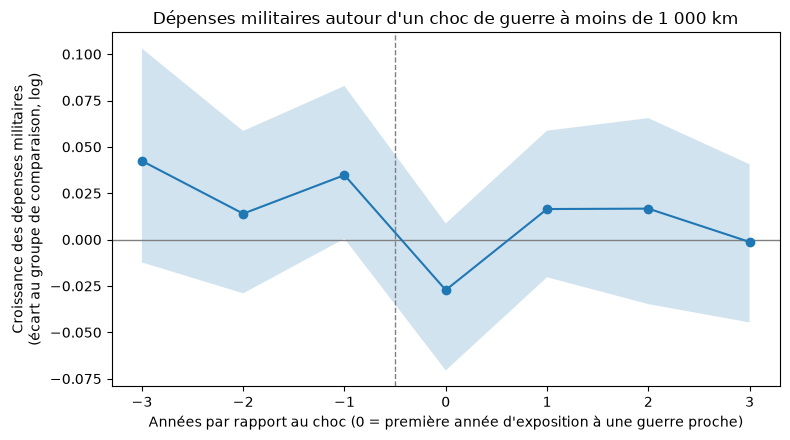

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Croissance winsorisée (1 % / 99 %) et groupe de comparaison de chaque année
lo, hi = panel["dlog_milex"].quantile([0.01, 0.99])
panel["dlog_w"] = panel["dlog_milex"].clip(lo, hi)

ctrl = panel[(panel["exp_war_1000"] == 0) & (panel["own_primary"] == 0)]
ctrl_mean = ctrl.groupby("year")[["dlog_w", "dlog_milex"]].mean().add_suffix("_ctrl")
print("Pays de comparaison par année (min / médiane) :",
      ctrl.groupby("year").size().min(), "/", ctrl.groupby("year").size().median())

panel = panel.drop(columns=[c for c in panel.columns if c.endswith("_ctrl")], errors="ignore")
panel = panel.merge(ctrl_mean, left_on="year", right_index=True, how="left")
panel["excess_w"] = panel["dlog_w"] - panel["dlog_w_ctrl"]
panel["excess_raw"] = panel["dlog_milex"] - panel["dlog_milex_ctrl"]

# 2. Événements : chocs "guerre", règle principale, jusqu'en 2022 (fenêtre complète)
ev = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1) & (panel["year"] <= 2022)][["gwno", "country", "year"]]
ev = ev.merge(src[["year", "country", "conflict_id"]], on=["year", "country"], how="left")
ev["episode"] = ev["year"].astype(str) + "_" + ev["conflict_id"].astype(str)
print(len(ev), "chocs jusqu'en 2022 |", ev["episode"].nunique(), "épisodes")

# 3. Empilement autour de chaque choc (k = -3 à +3)
idx = panel.set_index(["gwno", "year"])
rows = []
for e in ev.itertuples():
    for k in range(-3, 4):
        key = (e.gwno, e.year + k)
        if key in idx.index:
            r = idx.loc[key]
            rows.append((e.episode, e.gwno, k, r["excess_w"], r["excess_raw"]))
es = pd.DataFrame(rows, columns=["episode", "gwno", "k", "excess_w", "excess_raw"])
ep_k = es.groupby(["episode", "k"])[["excess_w", "excess_raw"]].mean().reset_index()

# 4. Moyenne par k et intervalle de confiance (bootstrap sur les épisodes)
def summarize(df, col, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    groups = {e: g for e, g in df.groupby("episode")}
    eps = list(groups)
    mean = df.groupby("k")[col].mean()
    boots = pd.DataFrame([
        pd.concat([groups[e] for e in rng.choice(eps, size=len(eps), replace=True)])
          .groupby("k")[col].mean()
        for _ in range(n_boot)])
    return pd.DataFrame({"moyenne": mean, "ic_bas": boots.quantile(0.025),
                         "ic_haut": boots.quantile(0.975), "n": df.groupby("k")[col].count()})

main = summarize(ep_k, "excess_w")      # principal : un épisode = un vote
pooled = summarize(es, "excess_w")      # robustesse : un pays-choc = un vote
raw = summarize(ep_k, "excess_raw")     # robustesse : sans winsorisation
print("\nPRINCIPAL :\n", main.round(3).to_string())
print("\nROBUSTESSE (un pays-choc = un vote) :\n", pooled.round(3).to_string())
print("\nROBUSTESSE (sans winsorisation) :\n", raw.round(3).to_string())

# 5. Graphique
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="grey", lw=1)
ax.axvline(-0.5, color="grey", ls="--", lw=1)
ax.plot(main.index, main["moyenne"], marker="o")
ax.fill_between(main.index, main["ic_bas"], main["ic_haut"], alpha=0.2)
ax.set_xlabel("Années par rapport au choc (0 = première année d'exposition à une guerre proche)")
ax.set_ylabel("Croissance des dépenses militaires\n(écart au groupe de comparaison, log)")
ax.set_title("Dépenses militaires autour d'un choc de guerre à moins de 1 000 km")
fig.tight_layout()
fig.savefig("../figures/event_study_principal.png", dpi=200)
plt.show()

panel.to_csv("../data/processed/panel_pays_annee.csv", index=False)

In [19]:
ep_tab = (es[es["k"].isin([-3, -2, -1, 1, 2, 3])]
          .assign(phase=lambda d: np.where(d["k"] < 0, "avant", "apres"))
          .groupby(["episode", "phase"])["excess_w"].mean().unstack())
ep_tab["diff"] = ep_tab["apres"] - ep_tab["avant"]
ep_tab["n_pays"] = es.groupby("episode")["gwno"].nunique()
ep_tab["guerre"] = [loc_name.get(int(float(e.split("_")[1])), "?") for e in ep_tab.index]

print(ep_tab.sort_values("n_pays", ascending=False).round(3).to_string())
print("\nÉpisodes avec diff > 0 :", int((ep_tab["diff"] > 0).sum()), "sur", len(ep_tab))

phase       apres  avant   diff  n_pays                                                     guerre
episode                                                                                           
2003_420    0.106  0.007  0.099       9  Australia, Iraq, United Kingdom, United States of America
2014_13246  0.098 -0.012  0.110       8                                                    Ukraine
2022_13243  0.070  0.031  0.039       8                             Russia (Soviet Union), Ukraine
1995_401    0.084  0.121 -0.037       6                                      Russia (Soviet Union)
2013_259   -0.028 -0.007 -0.021       5                                                       Iraq
2013_297   -0.011  0.101 -0.112       5                                                    Nigeria
1995_382    0.067 -0.109  0.176       4                                               Sierra Leone
2013_283   -0.073 -0.014 -0.059       3                                           DR Congo (Zaire)
2009_374  

In [21]:
resultats = []

def did_stat(df, col="excess_w", n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    groups = {e: g for e, g in df.groupby("episode")}
    eps = list(groups)
    def stat(d):
        m = d.groupby("k")[col].mean()
        return m.reindex([1, 2, 3]).mean() - m.reindex([-3, -2, -1]).mean()
    point = stat(df)
    boots = [stat(pd.concat([groups[e] for e in rng.choice(eps, size=len(eps), replace=True)]))
             for _ in range(n_boot)]
    return point, np.quantile(boots, 0.025), np.quantile(boots, 0.975)

def stack_events(shock_col, clean_col, drop=(), last_year=2022, col="excess_w"):
    ev_ = panel[(panel[shock_col] == 1) & (panel[clean_col] == 1) & (panel["year"] <= last_year)
                & (~panel["country"].isin(drop))][["gwno", "year"]].copy()
    idx_ = panel.set_index(["gwno", "year"])
    rows_ = []
    for e in ev_.itertuples():
        for k in range(-3, 4):
            key = (e.gwno, e.year + k)
            if key in idx_.index:
                rows_.append((e.year, k, idx_.loc[key, col]))
    d = pd.DataFrame(rows_, columns=["episode", "k", col]).dropna()
    d = d.groupby(["episode", "k"])[col].mean().reset_index()   # un cluster-année = un vote
    return len(ev_), d

def ajouter(nom, n, df, col="excess_w"):
    p, lo_, hi_ = did_stat(df, col)
    resultats.append((nom, n, df["episode"].nunique(), round(p, 3), round(lo_, 3), round(hi_, 3)))

# Famille A : un épisode (année x guerre) = un vote
ajouter("A. PRINCIPAL (un épisode = un vote)", len(ev), ep_k)
ajouter("A. Croissance brute (sans winsorisation)", len(ev), ep_k, "excess_raw")
ajouter("A. Un pays-choc = un vote", len(ev), es)

# Famille B : un cluster-année = un vote (variantes comparables entre elles)
for nom, sc, cc, drop in [
    ("B. Règle principale, regroupement par année", "shock_war_1000", "clean_prim", ()),
    ("B. Sans la Biélorussie", "shock_war_1000", "clean_prim", ("Belarus",)),
    ("B. Règle 'aucune implication'", "shock_war_1000", "clean_any", ()),
    ("B. Choc D9 (début d'exposition)", "shock_1000", "clean_prim", ()),
]:
    n, d = stack_events(sc, cc, drop)
    ajouter(nom, n, d)

print(pd.DataFrame(resultats, columns=["variante", "chocs", "clusters", "ecart_post_pre", "ic_bas", "ic_haut"]).to_string(index=False))
print("\nÉpisodes avec écart positif :", int((ep_tab["diff"] > 0).sum()), "sur", int(ep_tab["diff"].notna().sum()))

                                   variante  chocs  clusters  ecart_post_pre  ic_bas  ic_haut
        A. PRINCIPAL (un épisode = un vote)     79        28          -0.020  -0.060    0.020
   A. Croissance brute (sans winsorisation)     79        28          -0.024  -0.072    0.019
                  A. Un pays-choc = un vote     79        28           0.021  -0.024    0.054
B. Règle principale, regroupement par année     79        14          -0.009  -0.064    0.039
                     B. Sans la Biélorussie     76        14          -0.007  -0.064    0.043
              B. Règle 'aucune implication'     51        13          -0.008  -0.077    0.042
            B. Choc D9 (début d'exposition)     55        20           0.001  -0.033    0.030

Épisodes avec écart positif : 11 sur 25


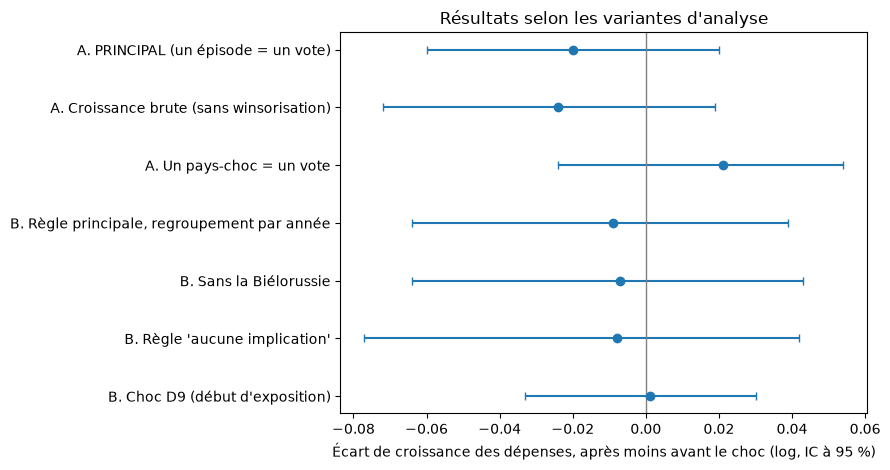

In [22]:
res = pd.DataFrame(resultats, columns=["variante", "chocs", "clusters", "ecart_post_pre", "ic_bas", "ic_haut"])
res.to_csv("../data/processed/resultats_robustesse.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(res))[::-1]
ax.errorbar(res["ecart_post_pre"], y,
            xerr=[res["ecart_post_pre"] - res["ic_bas"], res["ic_haut"] - res["ecart_post_pre"]],
            fmt="o", capsize=3)
ax.axvline(0, color="grey", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(res["variante"])
ax.set_xlabel("Écart de croissance des dépenses, après moins avant le choc (log, IC à 95 %)")
ax.set_title("Résultats selon les variantes d'analyse")
fig.tight_layout()
fig.savefig("../figures/robustesse_variantes.png", dpi=200)
plt.show()